# VehicleAI — Training Pipeline
**Final Year Project · M20010807010 · N.M. Shehan Dilhara Bandara**

This notebook reproduces the complete ML training pipeline for the VehicleAI engine fault detection system.

**Design decisions:**
- Noise injection replicates real OBD-II sensor tolerances
- Hard binary threshold flags **excluded** (avoid trivial overfitting)
- XGBoost with realistic hyperparameters (not overfit)
- 5-fold stratified CV reported alongside test metrics

In [7]:
# Install dependencies
import subprocess, sys
for pkg in ["xgboost","scikit-learn","pandas","numpy","matplotlib","seaborn","shap","joblib"]:
    subprocess.check_call([sys.executable,"-m","pip","install","-q",pkg])

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, shap, joblib, json
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import xgboost as xgb
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load Data

In [ ]:
# Set paths (update if needed)
DATA = "."   # folder containing sensor_readings.csv, fault_labels.csv, vehicle_metadata.csv

sensors = pd.read_csv(r"C:\Users\Shehan Dilhara\Desktop\Other\Final Proj\Final dataset\sensor_readings.csv")
faults = pd.read_csv(r"C:\Users\Shehan Dilhara\Desktop\Other\Final Proj\Final dataset\fault_labels.csv")
meta = pd.read_csv(r"C:\Users\Shehan Dilhara\Desktop\Other\Final Proj\Final dataset\vehicle_metadata.csv")

print(f"sensor_readings : {sensors.shape[0]:,} rows × {sensors.shape[1]} cols")
print(f"fault_labels    : {faults.shape[0]:,} rows")
print(f"vehicle_metadata: {meta.shape[0]:,} rows")

sensor_readings : 1,217 rows × 10 cols
fault_labels    : 1,217 rows
vehicle_metadata: 1,217 rows


## 2. Merge

In [8]:
df = sensors.merge(faults,on="reading_id").merge(meta,on="reading_id")
df.rename(columns={"mileage_km_x":"mileage_km","vehicle_id_x":"vehicle_id"},inplace=True)
df.drop(columns=["mileage_km_y","vehicle_id_y"],inplace=True,errors="ignore")
print(f"Merged: {df.shape}")
print("\nFault distribution:")
print(df["fault_label"].value_counts().to_string())

Merged: (1217, 18)

Fault distribution:
fault_label
Clutch Slip           210
Battery Fault         209
Engine Overheating    205
Oil Pressure Fault    203
Brake System Fault    200
Healthy               190


## 3. Quality Filter & Noise Injection

Noise levels based on published OBD-II sensor tolerances:
- engine_temp: ±1.5°C (NTC thermistor)
- battery_voltage: ±0.08V (ADC 10-bit)
- oil_pressure: ±1.2psi (piezoresistive)
- brake_fluid: ±2% (capacitive level)
- rpm: ±30rpm (crankshaft pulse)
- speed: ±1.5km/h (ABS wheel)

After filter: 1,217 rows
Noise injected ✓


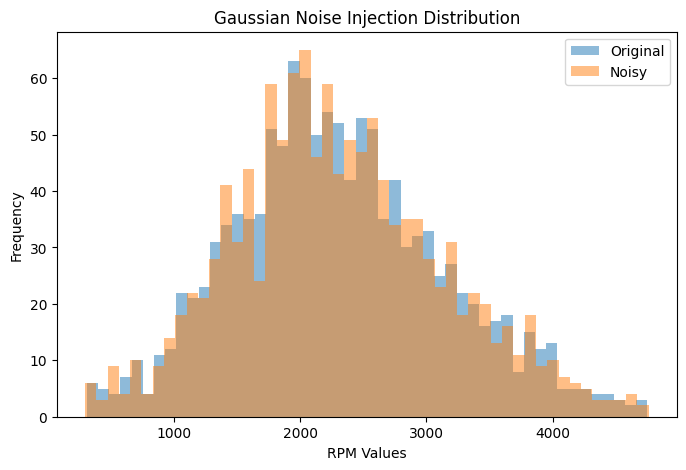

In [25]:
df = df[df["engine_temp_c"].between(50,130) & df["battery_voltage"].between(9,15) &
        df["oil_pressure_psi"].between(0,80) & df["brake_fluid_level_percent"].between(0,100) &
        df["rpm"].between(0,7000) & df["speed_kmh"].between(0,200)]
df.reset_index(drop=True,inplace=True)
print(f"After filter: {df.shape[0]:,} rows")

rng = np.random.default_rng(2025)
NOISE={"engine_temp_c":1.5,"battery_voltage":0.08,"oil_pressure_psi":1.2,
       "brake_fluid_level_percent":2.0,"rpm":30.0,"speed_kmh":1.5}
for col,sigma in NOISE.items():
    df[col]=df[col]+rng.normal(0,sigma,size=len(df))
df["engine_temp_c"]=df["engine_temp_c"].clip(50,130)
df["battery_voltage"]=df["battery_voltage"].clip(9,15)
df["oil_pressure_psi"]=df["oil_pressure_psi"].clip(0,80)
df["brake_fluid_level_percent"]=df["brake_fluid_level_percent"].clip(0,100)
df["rpm"]=df["rpm"].clip(0,7000).round().astype(int)
df["speed_kmh"]=df["speed_kmh"].clip(0,200).round().astype(int)
print("Noise injected ✓")

import matplotlib.pyplot as plt
import numpy as np

# Select original signal BEFORE noise injection
original_signal = df["rpm"].copy()

# Create noisy version
sigma = original_signal.std() * 0.05
noisy_signal = original_signal + np.random.normal(0, sigma, size=len(original_signal))

# Plot comparison
plt.figure(figsize=(8,5))

plt.hist(original_signal, bins=50, alpha=0.5, label="Original")
plt.hist(noisy_signal, bins=50, alpha=0.5, label="Noisy")

plt.xlabel("RPM Values")
plt.ylabel("Frequency")
plt.title("Gaussian Noise Injection Distribution")
plt.legend()

plt.show()

## 4. Feature Engineering

**Design decision:** Hard binary threshold flags (`overheat_flag`, `critical_oil_flag`, etc.) are **excluded**. These flags are proxies for the label itself and inflate accuracy without teaching the model real sensor relationships. Continuous ratio and interaction features are used instead.

In [10]:
df["battery_age_stress"]       = df["mileage_km"]/(df["battery_voltage"]+0.1)
df["voltage_deviation"]        = (df["battery_voltage"]-12.6).abs()
df["engine_stress_index"]      = df["engine_temp_c"]*df["rpm"]/1000
df["temp_mileage_interaction"] = df["engine_temp_c"]*np.log1p(df["mileage_km"])
df["traffic_heat_load"]        = df["engine_temp_c"]*(df["driving_pattern"]=="traffic").astype(int)
df["thermal_margin"]           = 115.0-df["engine_temp_c"]
df["oil_temp_ratio"]           = df["oil_pressure_psi"]/(df["engine_temp_c"]+1)
df["oil_pressure_deviation"]   = (df["oil_pressure_psi"]-40.0).abs()
df["brake_wear_index"]         = (100-df["brake_fluid_level_percent"])*df["speed_kmh"]
df["brake_fluid_margin"]       = df["brake_fluid_level_percent"]-50.0
df["rpm_speed_ratio"]          = df["rpm"]/(df["speed_kmh"]+1)
df["clutch_slip_index"]        = np.where(df["transmission"]=="Manual",df["rpm"]/(df["speed_kmh"]+1),0.0)
df["vehicle_age"]              = 2025-df["year"]
df["age_mileage_ratio"]        = df["mileage_km"]/(df["vehicle_age"]+1)
df["high_mileage_flag"]        = (df["mileage_km"]>150000).astype(int)
df["composite_health_score"]   = ((df["battery_voltage"]/14.4)*25+(df["oil_pressure_psi"]/55.0)*25+
                                   (df["brake_fluid_level_percent"]/95.0)*25+((130-df["engine_temp_c"])/55.0)*25).clip(0,100)
print(f"Total columns: {df.shape[1]}")

Total columns: 34


## 5. EDA

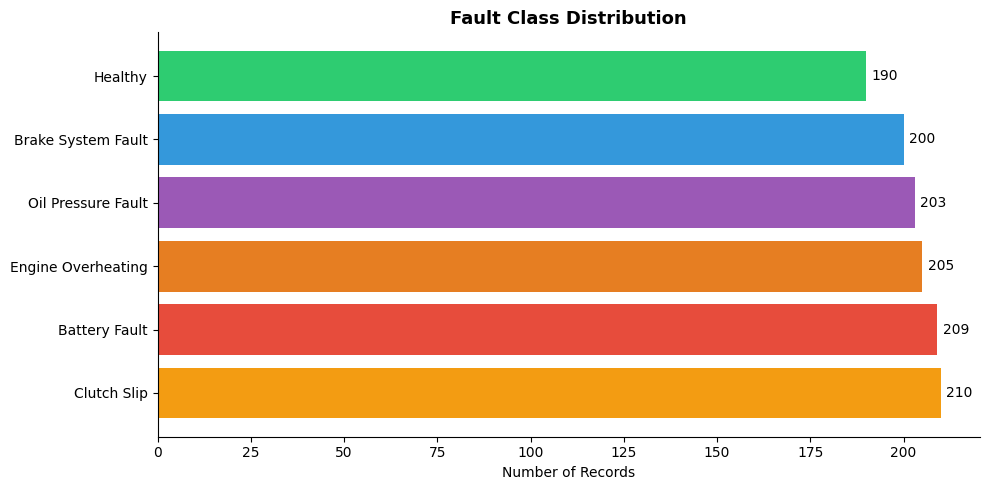

In [11]:
FAULT_PALETTE={"Healthy":"#2ecc71","Battery Fault":"#e74c3c","Engine Overheating":"#e67e22",
               "Oil Pressure Fault":"#9b59b6","Brake System Fault":"#3498db","Clutch Slip":"#f39c12"}

fig,ax=plt.subplots(figsize=(10,5))
order=df["fault_label"].value_counts().index
bars=ax.barh(order,df["fault_label"].value_counts()[order],color=[FAULT_PALETTE.get(l,"#888") for l in order])
ax.bar_label(bars,padding=4,fontsize=10)
ax.set_xlabel("Number of Records"); ax.set_title("Fault Class Distribution",fontsize=13,fontweight="bold")
ax.spines[["top","right"]].set_visible(False); plt.tight_layout(); plt.show()

## 6. Prepare Features

In [12]:
CAT_COLS=["make","model","engine_type","fuel_type","transmission","region_driven","driving_pattern"]
DROP_COLS=["fault_label","reading_id","vehicle_id"]
X=df.drop(columns=[c for c in DROP_COLS if c in df.columns])
NUM_COLS=[c for c in X.columns if c not in CAT_COLS]
le=LabelEncoder(); y=le.fit_transform(df["fault_label"])
print(f"Numeric features: {len(NUM_COLS)}")
print(f"Categorical features: {len(CAT_COLS)}")
print(f"Classes: {list(le.classes_)}")

Numeric features: 24
Categorical features: 7
Classes: ['Battery Fault', 'Brake System Fault', 'Clutch Slip', 'Engine Overheating', 'Healthy', 'Oil Pressure Fault']


## 7. Train / Test Split

In [13]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 973 | Test: 244


## 8. Preprocessor

In [15]:
preprocessor=ColumnTransformer([
    ("num",StandardScaler(),NUM_COLS),
    ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),CAT_COLS)
])

## 9. Train Models (7 algorithms)

In [17]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
pipelines = {}
best_obj = None
best_name = ""
best_f1 = 0.0

sklearn_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        C=1.0,
        solver="lbfgs",
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7,
        weights="distance"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.85,
        random_state=42
    ),

    "SVM": SVC(
        kernel="rbf",
        C=5.0,
        gamma="scale",
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.04,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.85,
        gamma=0.1,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    ),
}

for name, model in sklearn_models.items():

    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    acc = accuracy_score(y_test, preds)

    f1 = f1_score(
        y_test,
        preds,
        average="macro",
        zero_division=0
    )

    cv_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=CV,
        scoring="f1_macro",
        n_jobs=-1
    )

    print(
        f"[{name}] "
        f"Acc={acc:.4f}  "
        f"F1={f1:.4f}  "
        f"CV={cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
    )

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro F1": round(f1, 4),
        "CV F1 Mean": round(cv_scores.mean(), 4),
        "CV F1 Std": round(cv_scores.std(), 4)
    })

    pipelines[name] = pipe

    if f1 > best_f1:
        best_f1 = f1
        best_obj = pipe
        best_name = name

print(f"\n★ Best Model: {best_name} (F1={best_f1:.4f})")

[Logistic Regression] Acc=0.8566  F1=0.8564  CV=0.8192 ± 0.0263
[K-Nearest Neighbors] Acc=0.7910  F1=0.7892  CV=0.7669 ± 0.0230
[Random Forest] Acc=0.8443  F1=0.8422  CV=0.8250 ± 0.0151
[Gradient Boosting] Acc=0.8197  F1=0.8189  CV=0.8182 ± 0.0079
[SVM] Acc=0.8689  F1=0.8687  CV=0.8133 ± 0.0202
[XGBoost] Acc=0.8484  F1=0.8467  CV=0.8204 ± 0.0116

★ Best Model: SVM (F1=0.8687)


## 10. Results Table

In [18]:
results_df=pd.DataFrame(results).sort_values("Macro F1",ascending=False).reset_index(drop=True)
results_df.index+=1
print(results_df.to_string())

                 Model  Accuracy  Macro F1  CV F1 Mean  CV F1 Std
1                  SVM    0.8689    0.8687      0.8133     0.0202
2  Logistic Regression    0.8566    0.8564      0.8192     0.0263
3              XGBoost    0.8484    0.8467      0.8204     0.0116
4        Random Forest    0.8443    0.8422      0.8250     0.0151
5    Gradient Boosting    0.8197    0.8189      0.8182     0.0079
6  K-Nearest Neighbors    0.7910    0.7892      0.7669     0.0230


## 11. Confusion Matrix

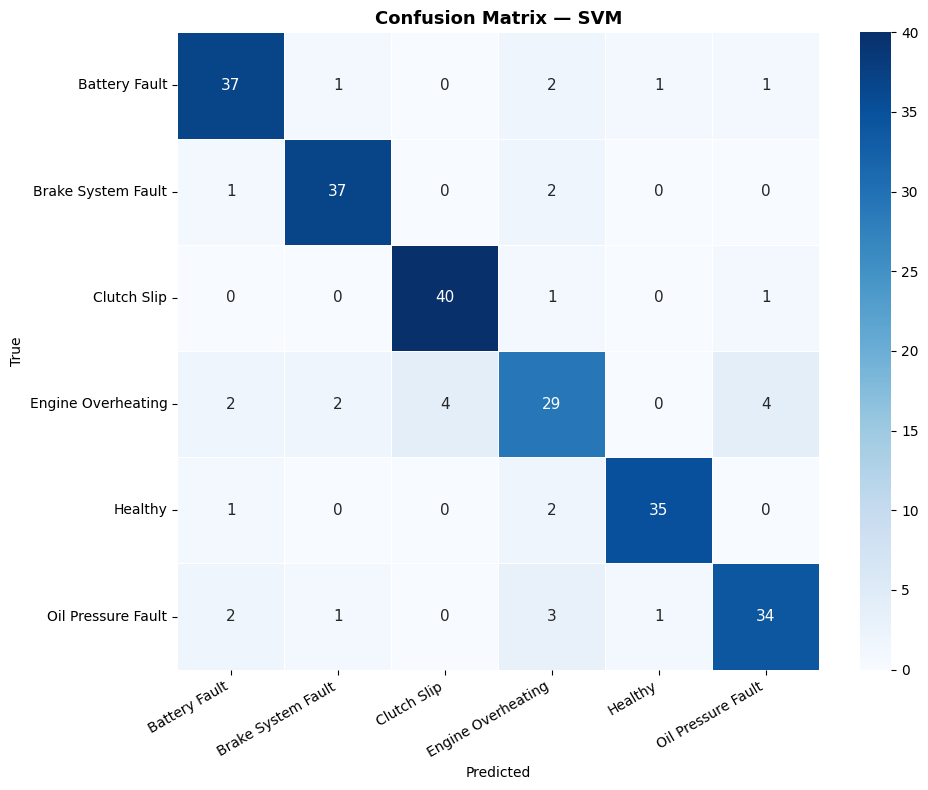

                    precision    recall  f1-score   support

     Battery Fault       0.86      0.88      0.87        42
Brake System Fault       0.90      0.93      0.91        40
       Clutch Slip       0.91      0.95      0.93        42
Engine Overheating       0.74      0.71      0.72        41
           Healthy       0.95      0.92      0.93        38
Oil Pressure Fault       0.85      0.83      0.84        41

          accuracy                           0.87       244
         macro avg       0.87      0.87      0.87       244
      weighted avg       0.87      0.87      0.87       244



In [19]:
best_preds=best_obj.predict(X_test)
cm=confusion_matrix(y_test,best_preds)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=le.classes_,yticklabels=le.classes_,linewidths=0.5,ax=ax,annot_kws={"size":11})
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(f"Confusion Matrix — {best_name}",fontsize=13,fontweight="bold")
plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()
print(classification_report(y_test,best_preds,target_names=le.classes_,zero_division=0))

## 12. Save Artefacts

In [20]:
joblib.dump(best_obj,"vehicle_fault_model.pkl")
joblib.dump(le,"label_encoder.pkl")
print("vehicle_fault_model.pkl  ✓")
print("label_encoder.pkl        ✓")

vehicle_fault_model.pkl  ✓
label_encoder.pkl        ✓


## 13. Single-Vehicle Prediction Demo

In [21]:
demo=pd.DataFrame([{"engine_temp_c":112.5,"rpm":2800,"battery_voltage":12.4,"oil_pressure_psi":16.0,
    "brake_fluid_level_percent":74.0,"speed_kmh":48,"mileage_km":145000,"driving_pattern":"mixed",
    "make":"Toyota","model":"Axio","year":2014,"engine_type":"4-cylinder",
    "fuel_type":"Petrol","transmission":"Automatic","region_driven":"Hokandara"}])

demo["battery_age_stress"]=demo["mileage_km"]/(demo["battery_voltage"]+0.1)
demo["voltage_deviation"]=(demo["battery_voltage"]-12.6).abs()
demo["engine_stress_index"]=demo["engine_temp_c"]*demo["rpm"]/1000
demo["temp_mileage_interaction"]=demo["engine_temp_c"]*np.log1p(demo["mileage_km"])
demo["traffic_heat_load"]=demo["engine_temp_c"]*(demo["driving_pattern"]=="traffic").astype(int)
demo["thermal_margin"]=115.0-demo["engine_temp_c"]
demo["oil_temp_ratio"]=demo["oil_pressure_psi"]/(demo["engine_temp_c"]+1)
demo["oil_pressure_deviation"]=(demo["oil_pressure_psi"]-40.0).abs()
demo["brake_wear_index"]=(100-demo["brake_fluid_level_percent"])*demo["speed_kmh"]
demo["brake_fluid_margin"]=demo["brake_fluid_level_percent"]-50.0
demo["rpm_speed_ratio"]=demo["rpm"]/(demo["speed_kmh"]+1)
demo["clutch_slip_index"]=np.where(demo["transmission"]=="Manual",demo["rpm"]/(demo["speed_kmh"]+1),0.0)
demo["vehicle_age"]=2025-demo["year"]
demo["age_mileage_ratio"]=demo["mileage_km"]/(demo["vehicle_age"]+1)
demo["high_mileage_flag"]=(demo["mileage_km"]>150000).astype(int)
demo["composite_health_score"]=((demo["battery_voltage"]/14.4)*25+(demo["oil_pressure_psi"]/55.0)*25+
    (demo["brake_fluid_level_percent"]/95.0)*25+((130-demo["engine_temp_c"])/55.0)*25).clip(0,100)
demo=demo[X_train.columns]

pred=le.inverse_transform(best_obj.predict(demo))[0]
proba=best_obj.predict_proba(demo)[0]
print(f"Predicted: {pred}  ({proba.max()*100:.1f}%)")
print("\nProbability breakdown:")
for cls,p in sorted(zip(le.classes_,proba),key=lambda x:-x[1]):
    print(f"  {cls:<25} {p*100:5.1f}%  {'█'*int(p*35)}")

Predicted: Oil Pressure Fault  (77.6%)

Probability breakdown:
  Oil Pressure Fault         77.6%  ███████████████████████████
  Engine Overheating         20.8%  ███████
  Clutch Slip                 0.8%  
  Battery Fault               0.4%  
  Brake System Fault          0.2%  
  Healthy                     0.2%  


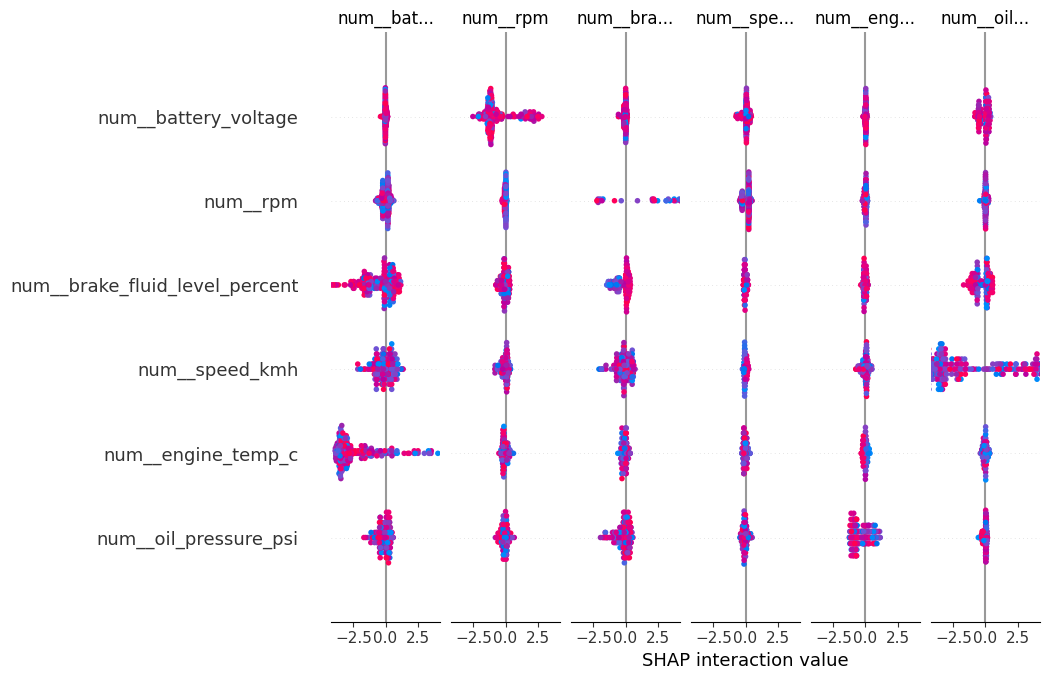

In [32]:
import shap
import matplotlib.pyplot as plt

# Select XGBoost pipeline directly
xgb_pipeline = pipelines["XGBoost"]

# Extract trained XGBoost model
xgb_model = xgb_pipeline.named_steps["model"]

# Transform test data
X_sample = xgb_pipeline.named_steps["prep"].transform(X_test)

# Feature names
feature_names = xgb_pipeline.named_steps["prep"].get_feature_names_out()

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Generate SHAP values
shap_values = explainer.shap_values(X_sample)

# SHAP beeswarm plot
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

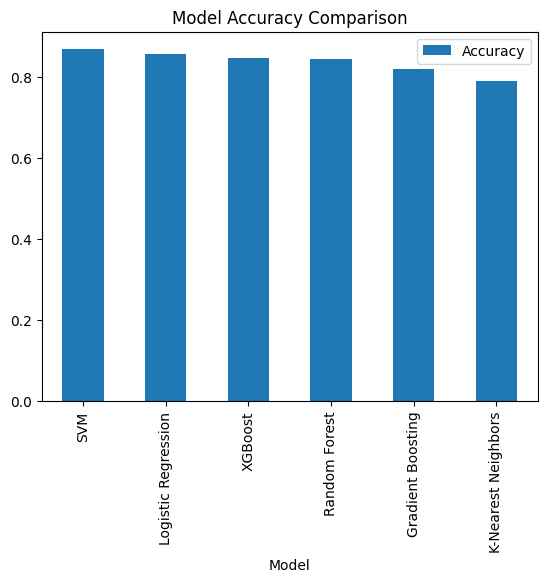

In [33]:
results_df.plot(x="Model", y="Accuracy", kind="bar")
plt.title("Model Accuracy Comparison")
plt.show()

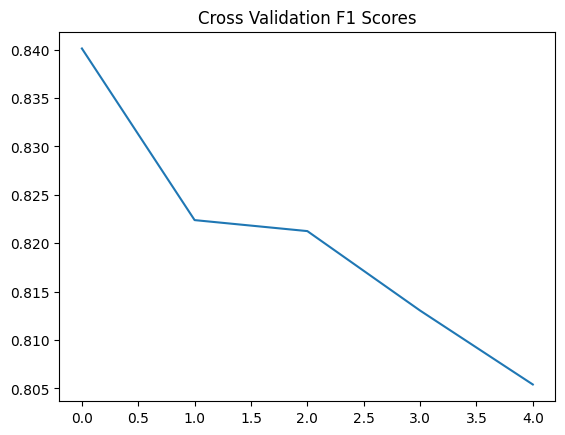

In [34]:
plt.plot(cv_scores)
plt.title("Cross Validation F1 Scores")
plt.show()